# DeliveryETA — Prédiction du Temps de Livraison

## Objectif du projet

L'objectif de ce projet est de développer un modèle de Machine Learning capable de prédire le temps nécessaire pour livrer une commande.

La variable cible du projet est :

`Time_taken(min)`

Le modèle utilisera différentes informations concernant la commande, le livreur, le trajet, le trafic, la météo et les conditions de livraison.

## Objectifs business

La prédiction du temps de livraison peut permettre de :

- fournir une estimation du délai au client ;
- améliorer la planification des livraisons ;
- aider à l'affectation des livreurs ;
- identifier les facteurs qui influencent le temps de livraison ;
- améliorer l'organisation des opérations de livraison.

## Dataset

Le dataset contient 45 593 observations et 20 variables.

Les informations disponibles concernent notamment :

- le livreur ;
- la position du restaurant et du client ;
- la date et l'heure de la commande ;
- les conditions météorologiques ;
- le trafic routier ;
- le véhicule ;
- le type de commande ;
- les livraisons multiples ;
- les festivals ;
- la ville ;
- le temps réel de livraison.

## Variable cible

La variable que nous voulons prédire est :

`Time_taken(min)`

Elle représente le temps de livraison en minutes.

## 1. Importation des bibliothèques

Nous importons les bibliothèques nécessaires pour charger, manipuler, analyser et visualiser les données.

In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

## 2. Chargement du dataset

Nous chargeons le fichier CSV contenant les données de livraison à l'aide de Pandas.

In [107]:
df = pd.read_csv("../data/dataset_food_delivery.csv")

## 3. Compréhension initiale des données

Avant de commencer le nettoyage, nous allons examiner la structure et les caractéristiques générales du dataset.

Nous allons vérifier :

- le nombre de lignes et de colonnes ;
- les noms des colonnes ;
- les premières observations ;
- les types de données ;
- les valeurs manquantes.

In [101]:
print(df.head())

        ID Delivery_person_ID Delivery_person_Age Delivery_person_Ratings  \
0  0x4607     INDORES13DEL02                   37                     4.9   
1  0xb379     BANGRES18DEL02                   34                     4.5   
2  0x5d6d     BANGRES19DEL01                   23                     4.4   
3  0x7a6a    COIMBRES13DEL02                   38                     4.7   
4  0x70a2     CHENRES12DEL01                   32                     4.6   

   Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
0            22.745049             75.892471                   22.765049   
1            12.913041             77.683237                   13.043041   
2            12.914264             77.678400                   12.924264   
3            11.003669             76.976494                   11.053669   
4            12.972793             80.249982                   13.012793   

   Delivery_location_longitude  Order_Date Time_Orderd Time_Order_picked  \
0   

In [98]:
print(df.shape)

(45593, 20)


In [99]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 45593 entries, 0 to 45592
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID                           45593 non-null  str    
 1   Delivery_person_ID           45593 non-null  str    
 2   Delivery_person_Age          45593 non-null  str    
 3   Delivery_person_Ratings      45593 non-null  str    
 4   Restaurant_latitude          45593 non-null  float64
 5   Restaurant_longitude         45593 non-null  float64
 6   Delivery_location_latitude   45593 non-null  float64
 7   Delivery_location_longitude  45593 non-null  float64
 8   Order_Date                   45593 non-null  str    
 9   Time_Orderd                  45593 non-null  str    
 10  Time_Order_picked            45593 non-null  str    
 11  Weatherconditions            45593 non-null  str    
 12  Road_traffic_density         45593 non-null  str    
 13  Vehicle_condition          

In [100]:
print(df.isnull().sum())

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weatherconditions              0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken(min)                0
dtype: int64


In [102]:
print(df.duplicated().sum())

0


In [104]:
print(df.columns.tolist())


['ID', 'Delivery_person_ID', 'Delivery_person_Age', 'Delivery_person_Ratings', 'Restaurant_latitude', 'Restaurant_longitude', 'Delivery_location_latitude', 'Delivery_location_longitude', 'Order_Date', 'Time_Orderd', 'Time_Order_picked', 'Weatherconditions', 'Road_traffic_density', 'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle', 'multiple_deliveries', 'Festival', 'City', 'Time_taken(min)']


In [ ]:
print(df.describe())

In [46]:
print(clean_df.dtypes)

Order_ID                    int64
Distance_km               float64
Weather                       str
Traffic_Level                 str
Time_of_Day                   str
Vehicle_Type                  str
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object


In [105]:
# last 5 rows
print(df.tail())

            ID Delivery_person_ID Delivery_person_Age Delivery_person_Ratings  \
45588  0x7c09      JAPRES04DEL01                   30                     4.8   
45589  0xd641      AGRRES16DEL01                   21                     4.6   
45590  0x4f8d     CHENRES08DEL03                   30                     4.9   
45591  0x5eee    COIMBRES11DEL01                   20                     4.7   
45592  0x5fb2   RANCHIRES09DEL02                   23                     4.9   

       Restaurant_latitude  Restaurant_longitude  Delivery_location_latitude  \
45588            26.902328             75.794257                   26.912328   
45589             0.000000              0.000000                    0.070000   
45590            13.022394             80.242439                   13.052394   
45591            11.001753             76.986241                   11.041753   
45592            23.351058             85.325731                   23.431058   

       Delivery_location_longitu

Cleaning Data


In [ ]:
clean_df = df.copy()
print(clean_df.duplicated().sum())
print(clean_df["ID"].duplicated().sum())

#print(clean_df["Traffic_Level"].value_counts())



0
0
<ArrowStringArray>
[  '37',   '34',   '23',   '38',   '32',   '22',   '33',   '35',   '36',
   '21',   '24',   '29',   '25',   '31',   '27',   '26',   '20', 'NaN ',
   '28',   '39']
Length: 20, dtype: str


###  Vérification des variables numériques

Certaines variables qui devraient être numériques sont actuellement stockées sous forme de texte (`str`).

Nous allons inspecter leurs valeurs avant de les convertir afin d'identifier d'éventuelles valeurs particulières ou incohérentes.

In [126]:
print(clean_df["Delivery_person_Age"].unique()[:30])
print(clean_df["Delivery_person_Ratings"].unique()[:30])
print(clean_df["multiple_deliveries"].unique())
print(clean_df["Time_taken(min)"].unique()[:20])

<ArrowStringArray>
[  '37',   '34',   '23',   '38',   '32',   '22',   '33',   '35',   '36',
   '21',   '24',   '29',   '25',   '31',   '27',   '26',   '20', 'NaN ',
   '28',   '39',   '30',   '15',   '50']
Length: 23, dtype: str
<ArrowStringArray>
[ '4.9',  '4.5',  '4.4',  '4.7',  '4.6',  '4.8',  '4.2',  '4.3',    '4',
  '4.1',    '5',  '3.5', 'NaN ',  '3.8',  '3.9',  '3.7',  '2.6',  '2.5',
  '3.6',  '3.1',  '2.7',    '1',  '3.2',  '3.3',    '6',  '3.4',  '2.8',
  '2.9',    '3']
Length: 29, dtype: str
<ArrowStringArray>
['0', '1', '3', 'NaN ', '2']
Length: 5, dtype: str
<ArrowStringArray>
['(min) 24', '(min) 33', '(min) 26', '(min) 21', '(min) 30', '(min) 40',
 '(min) 32', '(min) 34', '(min) 46', '(min) 23', '(min) 20', '(min) 41',
 '(min) 15', '(min) 36', '(min) 39', '(min) 18', '(min) 38', '(min) 47',
 '(min) 12', '(min) 22']
Length: 20, dtype: str


### 4.5 Nettoyage des valeurs manquantes textuelles

Certaines valeurs manquantes sont représentées sous forme de texte, par exemple `"NaN "`.

Pandas ne les considère donc pas comme de vraies valeurs manquantes.

Nous allons les remplacer par `NaN` afin que Pandas puisse les détecter et les traiter correctement.

In [131]:
clean_df = clean_df.replace("NaN ",np.nan)
print(clean_df.isnull().sum())


ID                                0
Delivery_person_ID                0
Delivery_person_Age            1854
Delivery_person_Ratings        1908
Restaurant_latitude               0
Restaurant_longitude              0
Delivery_location_latitude        0
Delivery_location_longitude       0
Order_Date                        0
Time_Orderd                    1731
Time_Order_picked                 0
Weatherconditions                 0
Road_traffic_density            601
Vehicle_condition                 0
Type_of_order                     0
Type_of_vehicle                   0
multiple_deliveries             993
Festival                        228
City                           1200
Time_taken(min)                   0
dtype: int64


###  Nettoyage de la variable cible

La variable cible `Time_taken(min)` contient actuellement le texte `(min)`.

Nous allons supprimer cette partie afin d'obtenir une variable numérique représentant le temps de livraison en minutes.

In [138]:
#clean_df["Time_taken(min)"] = (clean_df["Time_taken(min)"].str.replace("(min)","",regex=False).str.strip().astype(int))
print(clean_df["Time_taken(min)"].head)
print(clean_df["Time_taken(min)"].dtype)



<bound method NDFrame.head of 0        24
1        33
2        26
3        21
4        30
         ..
45588    32
45589    36
45590    16
45591    26
45592    36
Name: Time_taken(min), Length: 45593, dtype: int64>
int64


###  Analyse de la densité du trafic

La variable `Road_traffic_density` représente le niveau de trafic routier.

Il s'agit d'une variable catégorielle avec plusieurs niveaux :

- `Low` : trafic faible
- `Medium` : trafic moyen
- `High` : trafic élevé
- `Jam` : embouteillage important

Nous vérifions la fréquence de chaque catégorie ainsi que les valeurs manquantes.

In [145]:
print(clean_df["Road_traffic_density"].value_counts(dropna=False))

clean_df["Road_traffic_density"] = clean_df["Road_traffic_density"].fillna("Unknown")

print(clean_df["Road_traffic_density"].value_counts(dropna=False))


Road_traffic_density
Low        15477
Jam        14143
Medium     10947
High        4425
Unknown      601
Name: count, dtype: int64
Road_traffic_density
Low        15477
Jam        14143
Medium     10947
High        4425
Unknown      601
Name: count, dtype: int64


### Vérification de `multiple_deliveries`

La variable `multiple_deliveries` indique le nombre de livraisons multiples associées à une commande.

Nous allons vérifier la fréquence de chaque valeur, y compris les valeurs manquantes.

In [154]:
print(clean_df["multiple_deliveries"].value_counts(dropna=False))
clean_df["multiple_deliveries"].dtype

clean_df["multiple_deliveries"] = pd.to_numeric(
    clean_df["multiple_deliveries"],
    errors="coerce" # valuee can't converted = NaN not stop convert
)

multiple_deliveries
1.0    28159
0.0    14095
2.0     1985
NaN      993
3.0      361
Name: count, dtype: int64


### Vérification de `Delivery_person_Age`

La variable `Delivery_person_Age` représente l'âge du livreur.

Avant de convertir cette colonne en numérique, nous allons vérifier :
- les différentes valeurs présentes ;
- les valeurs manquantes ;
- la distribution des âges ;
- la présence éventuelle de valeurs inhabituelles.

In [166]:
clean_df["Delivery_person_Age"].value_counts(dropna=False).sort_index()

clean_df["Delivery_person_Age"]= pd.to_numeric(
    clean_df["Delivery_person_Age"],
    errors="coerce"
)

clean_df["Delivery_person_Age"].describe()

count    43739.000000
mean        29.567137
std          5.815155
min         15.000000
25%         25.000000
50%         30.000000
75%         35.000000
max         50.000000
Name: Delivery_person_Age, dtype: float64

In [76]:
clean_df[
    [
        "Distance_km",
        "Preparation_Time_min",
        "Courier_Experience_yrs",
        "Delivery_Time_min"
    ]
].describe()

,Distance_km,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,10.059970,16.982000,4.592000,56.732000
std,5.696656,7.204553,2.871198,22.070915
min,0.590000,5.000000,0.000000,8.000000
25%,5.105000,11.000000,2.000000,41.000000
50%,10.190000,17.000000,5.000000,55.500000
75%,15.017500,23.000000,7.000000,71.000000
max,19.990000,29.000000,9.000000,153.000000


### 4.4 Détection des valeurs aberrantes

Nous examinons les variables numériques afin d'identifier les valeurs potentiellement aberrantes. Une valeur aberrante n'est pas nécessairement une erreur : elle doit être analysée avant de décider de la conserver ou de la supprimer.

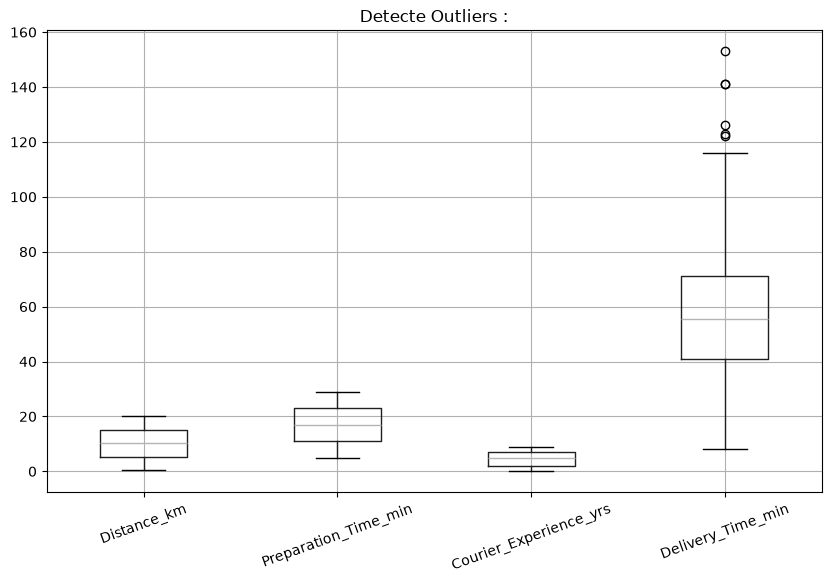

In [77]:
numerical_cols = [
    "Distance_km",
    "Preparation_Time_min",
    "Courier_Experience_yrs",
    "Delivery_Time_min"
]

clean_df[numerical_cols].boxplot(figsize=(10, 6))
plt.title("Detecte Outliers :")
plt.xticks(rotation=20)
plt.show()

In [78]:
print(clean_df["Delivery_Time_min"].describe())

Q1 = clean_df["Delivery_Time_min"].quantile(0.25)
Q3 = clean_df["Delivery_Time_min"].quantile(0.75)

IQR = Q3 - Q1
print(f"IQR : {IQR}")
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(f"loweer bounf : {lower_bound}")
print(f"upper bound : {upper_bound}")

delivery_outliers = clean_df[
    (clean_df["Delivery_Time_min"] < lower_bound) |
    (clean_df["Delivery_Time_min"] > upper_bound)
]

print("Numbeeeer of outliersss:", len(delivery_outliers))

count    1000.000000
mean       56.732000
std        22.070915
min         8.000000
25%        41.000000
50%        55.500000
75%        71.000000
max       153.000000
Name: Delivery_Time_min, dtype: float64
IQR : 30.0
loweer bounf : -4.0
upper bound : 116.0
Numbeeeer of outliersss: 6


In [ ]:
#clean_df = clean_df[
#    (clean_df["Delivery_Time_min"] >= lower_bound) &
#    (clean_df["Delivery_Time_min"] <= upper_bound)
#]

#print(clean_df.describe())

          Order_ID  Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
count   994.000000   994.000000            994.000000              994.000000   
mean    500.085513    10.016308             16.959759                4.595573   
std     289.113713     5.684717              7.206240                2.876340   
min       1.000000     0.590000              5.000000                0.000000   
25%     249.250000     5.015000             11.000000                2.000000   
50%     501.500000    10.150000             17.000000                5.000000   
75%     749.750000    14.890000             23.000000                7.000000   
max    1000.000000    19.990000             29.000000                9.000000   

       Delivery_Time_min  
count         994.000000  
mean           56.263581  
std            21.276034  
min             8.000000  
25%            41.000000  
50%            55.000000  
75%            71.000000  
max           116.000000  


###  Vérification des variables catégorielles

Nous vérifions les valeurs présentes dans les variables catégorielles afin d'identifier d'éventuelles valeurs incohérentes, espaces inutiles ou catégories inattendues.


In [80]:
categorical_cols = [
    "Weather",
    "Traffic_Level",
    "Time_of_Day",
    "Vehicle_Type"
]

for col in categorical_cols:
    print(f"\n--- {col} ---")
    print(clean_df[col].value_counts(dropna=False))


--- Weather ---
Weather
Clear    500
Rainy    204
Foggy    103
Snowy     97
Windy     96
Name: count, dtype: int64

--- Traffic_Level ---
Traffic_Level
Medium    420
Low       383
High      197
Name: count, dtype: int64

--- Time_of_Day ---
Time_of_Day
Morning      338
Evening      293
Afternoon    284
Night         85
Name: count, dtype: int64

--- Vehicle_Type ---
Vehicle_Type
Bike       503
Scooter    302
Car        195
Name: count, dtype: int64


###  Vérification finale après nettoyage

Nous effectuons une dernière vérification des valeurs manquantes, des doublons et de la structure du dataset avant de passer à l'analyse exploratoire.

In [81]:
print("Valeurs manquantes :")
print(clean_df.isnull().sum())

print("\nNombre de doublons :", clean_df.duplicated().sum())

print("\nDimensions :", clean_df.shape)

print("\nTypes :")
print(clean_df.dtypes)

Valeurs manquantes :
Order_ID                  0
Distance_km               0
Weather                   0
Traffic_Level             0
Time_of_Day               0
Vehicle_Type              0
Preparation_Time_min      0
Courier_Experience_yrs    0
Delivery_Time_min         0
dtype: int64

Nombre de doublons : 0

Dimensions : (1000, 9)

Types :
Order_ID                    int64
Distance_km               float64
Weather                       str
Traffic_Level                 str
Time_of_Day                   str
Vehicle_Type                  str
Preparation_Time_min        int64
Courier_Experience_yrs    float64
Delivery_Time_min           int64
dtype: object


## 5. Analyse Exploratoire des Données (EDA)

L'objectif de cette étape est de comprendre les données avant de construire les modèles de Machine Learning.

Nous allons analyser :
- les statistiques descriptives ;
- la distribution du temps de livraison ;
- les variables numériques ;
- les variables catégorielles ;
- les relations entre les variables et le temps de livraison ;
- les corrélations entre les variables numériques.

### 5.1 Statistiques descriptives

Nous commençons par analyser les statistiques descriptives des variables numériques.

Cette analyse permet d'observer notamment :
- la moyenne ;
- la médiane ;
- l'écart-type ;
- les valeurs minimale et maximale ;
- les quartiles.

In [82]:
print(clean_df.describe())

          Order_ID  Distance_km  Preparation_Time_min  Courier_Experience_yrs  \
count  1000.000000  1000.000000           1000.000000             1000.000000   
mean    500.500000    10.059970             16.982000                4.592000   
std     288.819436     5.696656              7.204553                2.871198   
min       1.000000     0.590000              5.000000                0.000000   
25%     250.750000     5.105000             11.000000                2.000000   
50%     500.500000    10.190000             17.000000                5.000000   
75%     750.250000    15.017500             23.000000                7.000000   
max    1000.000000    19.990000             29.000000                9.000000   

       Delivery_Time_min  
count        1000.000000  
mean           56.732000  
std            22.070915  
min             8.000000  
25%            41.000000  
50%            55.500000  
75%            71.000000  
max           153.000000  


### 5.2 Analyse de la variable cible

La variable cible `Delivery_Time_min` représente le temps total de livraison en minutes.

Nous analysons sa distribution afin de comprendre les temps de livraison observés dans le dataset avant de construire le modèle.

In [84]:
clean_df["Delivery_Time_min"].describe()


count    1000.000000
mean       56.732000
std        22.070915
min         8.000000
25%        41.000000
50%        55.500000
75%        71.000000
max       153.000000
Name: Delivery_Time_min, dtype: float64

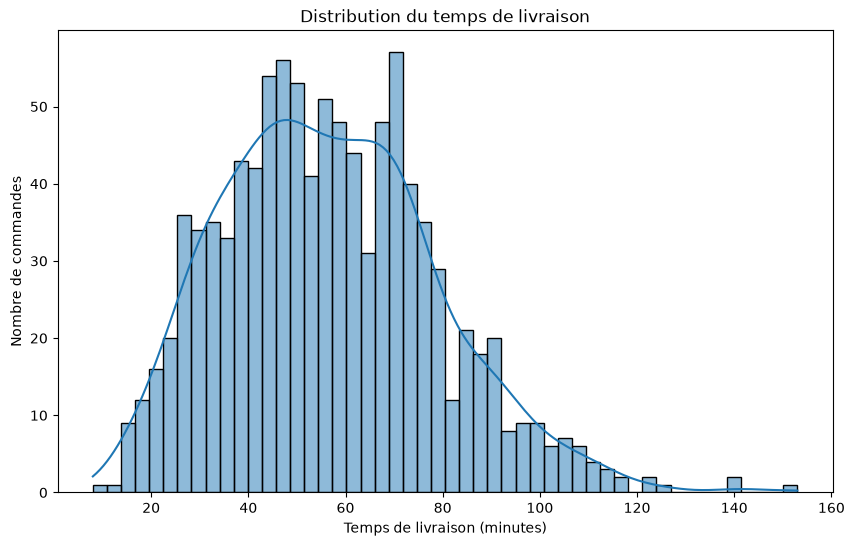

In [87]:
plt.figure(figsize=(10, 6))

sns.histplot(
    clean_df["Delivery_Time_min"],
    bins=50,
    kde=True
)

plt.title("Distribution du temps de livraison")
plt.xlabel("Temps de livraison (minutes)")
plt.ylabel("Nombre de commandes")

plt.show()

### 5.3 Relation entre le temps de livraison et les variables numériques

Nous analysons maintenant la relation entre `Delivery_Time_min` et les variables numériques :

- `Distance_km`
- `Preparation_Time_min`
- `Courier_Experience_yrs`

L'objectif est d'identifier les variables qui semblent avoir une influence sur le temps de livraison.

## 1. Distance vs delivery time

<Figure size 1000x600 with 0 Axes>

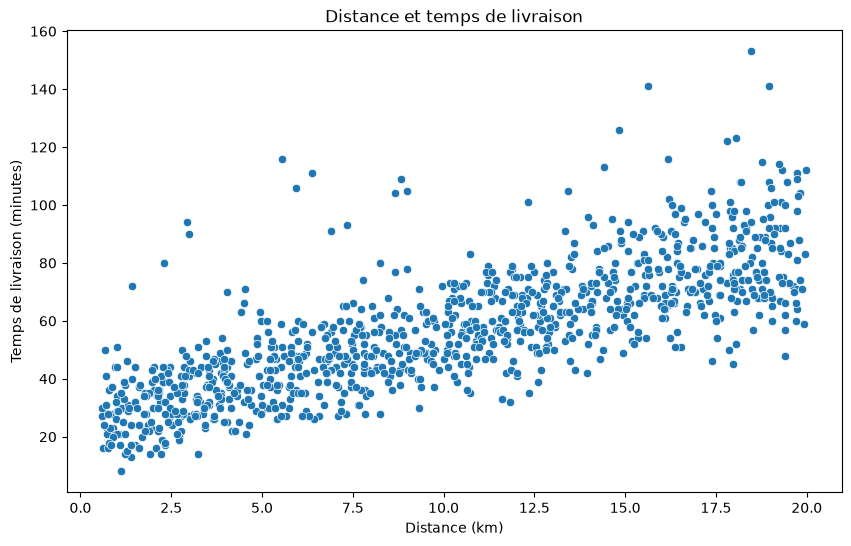

In [89]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_df,
    x="Distance_km",
    y="Delivery_Time_min"
)

plt.title("Distance et temps de livraison")
plt.xlabel("Distance (km)")
plt.ylabel("Temps de livraison (minutes)")

plt.show()

## 2. Preparation time vs delivery time

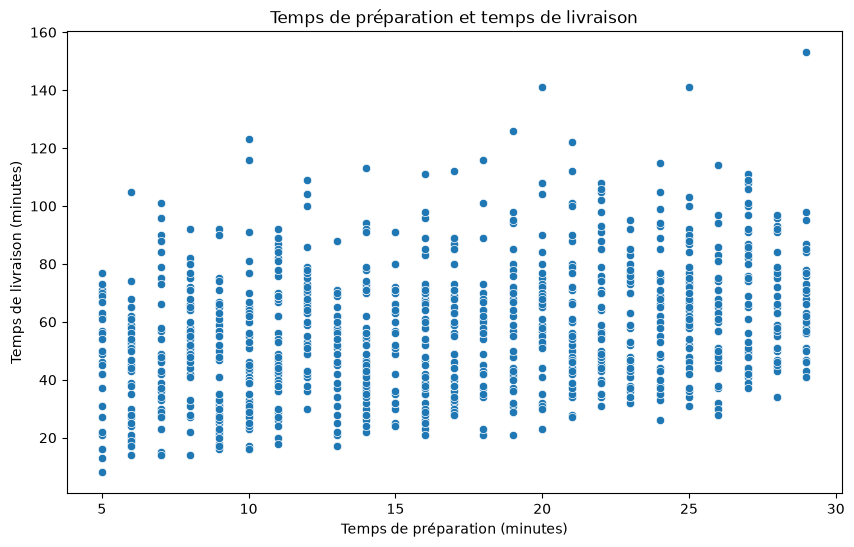

In [90]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_df,
    x="Preparation_Time_min",
    y="Delivery_Time_min"
)

plt.title("Temps de préparation et temps de livraison")
plt.xlabel("Temps de préparation (minutes)")
plt.ylabel("Temps de livraison (minutes)")

plt.show()

## 3. Courier experience vs delivery time

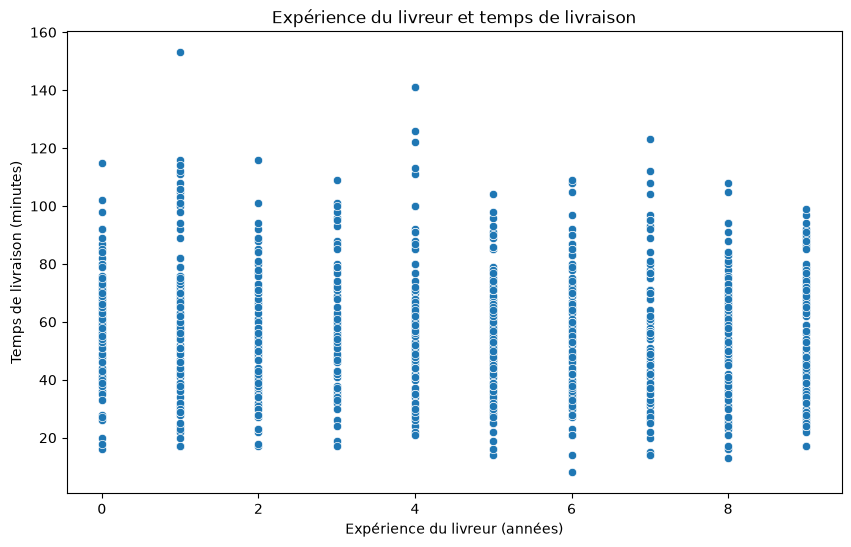

In [91]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=clean_df,
    x="Courier_Experience_yrs",
    y="Delivery_Time_min"
)

plt.title("Expérience du livreur et temps de livraison")
plt.xlabel("Expérience du livreur (années)")
plt.ylabel("Temps de livraison (minutes)")

plt.show()

### 5.4 Relation entre les variables catégorielles et le temps de livraison

Nous comparons le temps de livraison selon les différentes catégories de :
- `Weather`
- `Traffic_Level`
- `Time_of_Day`
- `Vehicle_Type`

Les boxplots permettent de comparer la médiane, la dispersion et les valeurs potentiellement atypiques entre les catégories.

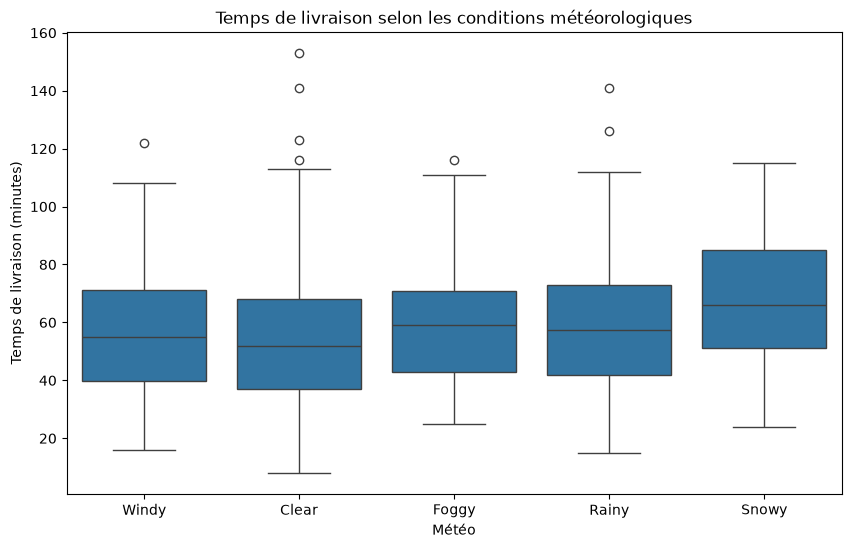

In [92]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=clean_df,
    x="Weather",
    y="Delivery_Time_min"
)

plt.title("Temps de livraison selon les conditions météorologiques")
plt.xlabel("Météo")
plt.ylabel("Temps de livraison (minutes)")

plt.show()

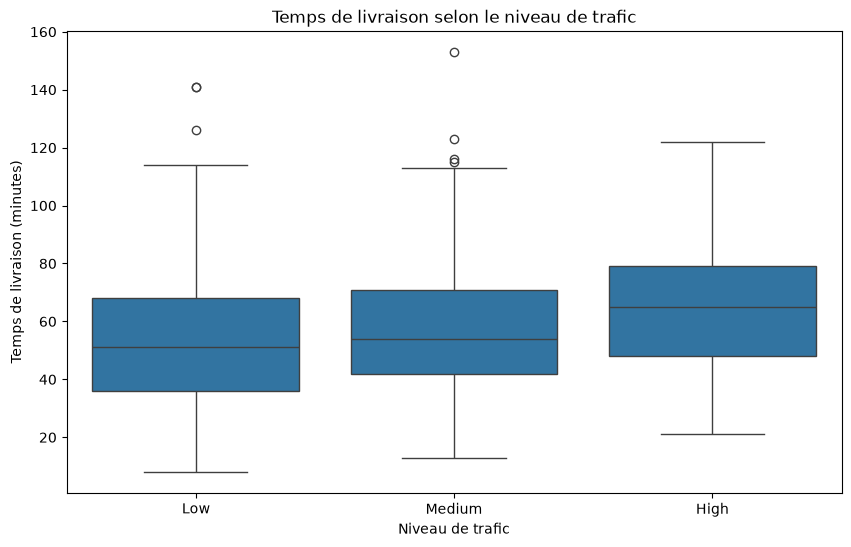

In [93]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=clean_df,
    x="Traffic_Level",
    y="Delivery_Time_min"
)

plt.title("Temps de livraison selon le niveau de trafic")
plt.xlabel("Niveau de trafic")
plt.ylabel("Temps de livraison (minutes)")

plt.show()